# HW4 - Two-Stream Shortwave Radiative Transfer and the Aerosol Direct Radiative Effect
+ Myles Jacobs
+ SIOC251
### Preface - Importing the data

In [4]:
import numpy as np
import pandas as pd
import os

# Let's double-check what is in your current directory first
print("Current Working Directory contents:", os.listdir('.'))

# Corrected paths pointing to the 'data' folder
aerosol_path = 'data/aerosol_properties.csv'
reflectance_path = 'data/ocean_reflectance.csv'

# Safe loading wrapper to prevent crashes
if os.path.exists(aerosol_path) and os.path.exists(reflectance_path):
    # 1. Load the data
    aerosol_df = pd.read_csv(aerosol_path)
    reflectance_df = pd.read_csv(reflectance_path)
    
    # Extract wavelengths
    wavelengths = aerosol_df['lambda (mu)'].values  # 0.4 to 4.0 um

    # 2. Define Rayleigh Layer Properties (Layer 2, Bottom)
    tau_R = 0.1 * (0.55 / wavelengths) ** 4
    omega_R = np.ones_like(wavelengths)
    g_R = np.zeros_like(wavelengths)

    # 3. Define Aerosol Layer Properties (Layer 1, Top)
    tau_dust = 1.0 * aerosol_df['dust Be'].values
    omega_dust = aerosol_df['dust omega'].values
    g_dust = aerosol_df['dust g'].values

    # Pollution
    tau_poll = 1.0 * aerosol_df['pollution Be'].values
    omega_poll = aerosol_df['pollution omega'].values
    g_poll = aerosol_df['pollution g'].values

    # 4. Surface boundary condition (Ocean Albedo)
    r_surface = reflectance_df['reflectance'].values

    print(f"\nSuccess! Loaded {len(wavelengths)} wavelength bins.")
    print(f"At 0.5 um: Tau_Rayleigh = {tau_R[1]:.3f}, Tau_Dust = {tau_dust[1]:.3f}")
else:
    print("\n[Error] Still can't find the files. If 'data' isn't visible here, "
          "you might need to use '../data/aerosol_properties.csv' instead.")

Current Working Directory contents: ['.ipynb_checkpoints', 'data', 'figures', 'two-steam-aerosol-DRE.ipynb', 'two_stream_aerosol_DRE(real).ipynb']

Success! Loaded 37 wavelength bins.
At 0.5 um: Tau_Rayleigh = 0.146, Tau_Dust = 1.104


## Part I - Two Stream Model Construction
### 5.1 - Building the Scattering Model
Based on Grant Petty's *A First Course in Atmospheric Radiation* (Ch. 13), the two-stream equations for diffuse incidence define the reflectance ($R$) and transmittance ($T$) of an isolated atmospheric layer using its optical depth $\tau$, single-scattering albedo $\omega$, and asymmetry parameter $g$. 

The foundational parameters are the **diffuse backscatter fraction** and the **diffusivity factor**:
* $b = \frac{1 - g}{2}$
* $\bar{\mu} = 0.5$

**Case A: Conservative Scattering ($\omega = 1$)**
For layers with no absorption (like the Rayleigh layer):
$$R = \frac{b\tau}{\bar{\mu} + b\tau}$$
$$T = \frac{\bar{\mu}}{\bar{\mu} + b\tau}$$

**Case B: Non-Conservative Scattering ($\omega < 1$)**
For layers that absorb radiation (like the aerosol layers), intermediate terms are required to account for exponential decay:
$$K = \frac{1}{\bar{\mu}} \sqrt{(1 - \omega)(1 - \omega + 2\omega b)}$$
$$\alpha = \sqrt{\frac{1 - \omega}{1 - \omega + 2\omega b}}$$
$$R_\infty = \frac{1 - \alpha}{1 + \alpha}$$

The reflectance and transmittance are then calculated as:
$$R = \frac{R_\infty (1 - e^{-2K\tau})}{1 - R_\infty^2 e^{-2K\tau}}$$
$$T = \frac{(1 - R_\infty^2) e^{-K\tau}}{1 - R_\infty^2 e^{-2K\tau}}$$

In [6]:
def solve_single_layer(tau, omega, g, mu_bar=0.5):
    """
    Calculates the Reflectance (R) and Transmittance (T) of a single isolated layer
    using Grant Petty's Chapter 13 Two-Stream diffuse incidence equations.
    """
    # Calculate diffuse backscatter fraction
    b = (1.0 - g) / 2.0
    
    # Initialize arrays for R and T matching the shape of input vectors
    R = np.zeros_like(tau)
    T = np.zeros_like(tau)
    
    # Condition masks to separate conservative vs non-conservative scattering safely
    conservative = (omega >= 0.99999)
    non_conservative = ~conservative
    
    # --- Case A: Conservative Scattering (omega == 1) ---
    if np.any(conservative):
        t_c = tau[conservative]
        b_c = b[conservative]
        
        R[conservative] = (b_c * t_c) / (mu_bar + b_c * t_c)
        T[conservative] = mu_bar / (mu_bar + b_c * t_c)
        
    # --- Case B: Non-Conservative Scattering (omega < 1) ---
    if np.any(non_conservative):
        t_nc = tau[non_conservative]
        w_nc = omega[non_conservative]
        b_nc = b[non_conservative]
        
        # Calculate intermediate parameters K and alpha
        K = (1.0 / mu_bar) * np.sqrt((1.0 - w_nc) * (1.0 - w_nc + 2.0 * w_nc * b_nc))
        alpha = np.sqrt((1.0 - w_nc) / (1.0 - w_nc + 2.0 * w_nc * b_nc))
        
        # Calculate R_infinity
        R_inf = (1.0 - alpha) / (1.0 + alpha)
        
        # Exponential terms
        exp_minus_K_tau = np.exp(-K * t_nc)
        exp_minus_2K_tau = np.exp(-2.0 * K * t_nc)
        
        # Final R and T for non-conservative wavelengths
        denom = 1.0 - (R_inf**2) * exp_minus_2K_tau
        R[non_conservative] = (R_inf * (1.0 - exp_minus_2K_tau)) / denom
        T[non_conservative] = ((1.0 - R_inf**2) * exp_minus_K_tau) / denom
        
    return R, T

### Combining Layers: The Stacking Method
When light travels through multiple layers, it undergoes infinite back-and-forth reflections between layer boundaries. To couple **Layer 1** (Aerosol, top) and **Layer 2** (Rayleigh, bottom), we use the layer-adding equations.

The combined reflectance ($R_{12}$) and transmittance ($T_{12}$) of the two-layer atmosphere are:
$$R_{12} = R_1 + \frac{T_1^2 R_2}{1 - R_1 R_2}$$
$$T_{12} = \frac{T_1 T_2}{1 - R_1 R_2}$$

To resolve the entire system's radiative transfer, this stacking method is applied one final time. The joint atmosphere ($R_{12}$, $T_{12}$) is coupled with the ocean surface reflectance ($R_s$) to calculate the definitive Top-of-Atmosphere (TOA) albedo and net surface transmittance.

In [7]:
def run_two_stream_model(tau_aerosol, omega_aerosol, g_aerosol, tau_rayleigh, omega_rayleigh, g_rayleigh, r_surface):
    """
    Stacks the Aerosol layer, Rayleigh layer, and Ocean surface together.
    Returns:
      - Albedo at TOA (system reflectance)
      - Transmittance at the surface
    """
    # 1. Solve individual layers
    R1, T1 = solve_single_layer(tau_aerosol, omega_aerosol, g_aerosol)
    R2, T2 = solve_single_layer(tau_rayleigh, omega_rayleigh, g_rayleigh)
    
    # 2. Combine Layer 1 (Top: Aerosol) and Layer 2 (Bottom: Rayleigh)
    denom_atmosphere = 1.0 - R1 * R2
    R12 = R1 + (T1**2 * R2) / denom_atmosphere
    T12 = (T1 * T2) / denom_atmosphere
    
    # 3. Combine the atmosphere with the Ocean Surface (r_surface)
    # Albedo at TOA includes reflections back from the surface through the atmosphere
    albedo_toa = R12 + (T12**2 * r_surface) / (1.0 - R12 * r_surface)
    
    # Net total transmittance reaching the surface (including multiple surface reflections)
    transmittance_sfc = T12 / (1.0 - R12 * r_surface)
    
    return albedo_toa, transmittance_sfc

In [8]:
# Calculate for Dust profile
albedo_dust, trans_dust = run_two_stream_model(
    tau_dust, omega_dust, g_dust, 
    tau_R, omega_R, g_R, 
    r_surface
)

print("Model successfully built!")
print(f"At wavelength 0.5 um, Dust System Albedo (TOA): {albedo_dust[1]:.4f}")
print(f"At wavelength 0.5 um, Dust System Transmittance (SFC): {trans_dust[1]:.4f}")

Model successfully built!
At wavelength 0.5 um, Dust System Albedo (TOA): 0.3286
At wavelength 0.5 um, Dust System Transmittance (SFC): 0.6168


### 5.2 - Model Verification

**Limiting Case One:** Optically thin layers: $\tau_{R} = 0.0$ and $\tau_{dust}, \tau_{poll} = 0$. We should expect a transmittance to equal exactly 1.0 and a reflectance equal to exactly the surface reflectance $r_{s}$ given by the ocean_reflectance data.

In [9]:
# 1. Create zero-optical depth arrays matching the wavelength grid size
tau_zero = np.zeros_like(wavelengths)

# 2. Run the model for "Dust" parameters but with zero optical depth
albedo_test1_dust, trans_test1_dust = run_two_stream_model(
    tau_zero, omega_dust, g_dust,
    tau_zero, omega_R, g_R,
    r_surface
)

# 3. Run the model for "Pollution" parameters with zero optical depth
albedo_test1_poll, trans_test1_poll = run_two_stream_model(
    tau_zero, omega_poll, g_poll,
    tau_zero, omega_R, g_R,
    r_surface
)

# 4. Automate the verification checks using numpy's allclose
trans_passed_dust = np.allclose(trans_test1_dust, 1.0)
albedo_passed_dust = np.allclose(albedo_test1_dust, r_surface)

trans_passed_poll = np.allclose(trans_test1_poll, 1.0)
albedo_passed_poll = np.allclose(albedo_test1_poll, r_surface)

# Print out results
print("=== VERIFICATION TEST 1 RESULTS ===")
print(f"Dust Profile - Surface Transmittance is 1.0 everywhere?      {trans_passed_dust}")
print(f"Dust Profile - TOA Albedo equals Ocean Reflectance?          {albedo_passed_dust}")
print(f"Pollution Profile - Surface Transmittance is 1.0 everywhere? {trans_passed_poll}")
print(f"Pollution Profile - TOA Albedo equals Ocean Reflectance?     {albedo_passed_poll}")

if trans_passed_dust and albedo_passed_dust and trans_passed_poll and albedo_passed_poll:
    print("\n✅ PASSED: The model behaves exactly as expected for a vacuum atmosphere!")
else:
    print("\n❌ FAILED: Please check the single-layer or layer-adding math equations.")

=== VERIFICATION TEST 1 RESULTS ===
Dust Profile - Surface Transmittance is 1.0 everywhere?      True
Dust Profile - TOA Albedo equals Ocean Reflectance?          True
Pollution Profile - Surface Transmittance is 1.0 everywhere? True
Pollution Profile - TOA Albedo equals Ocean Reflectance?     True

✅ PASSED: The model behaves exactly as expected for a vacuum atmosphere!


**Limiting Case Two:** No albedo and optically thick atmosphere: $\omega_{dust} = \omega_{poll} = \omega_{R} = 0$, and $\tau_{i} \rightarrow \infty$. We should expect, for all wavelengths and corresponding optical depths, a resulting ToA albedo to be 0.0 and a transmittance to be zero as well, as all light is absorbed by the atmosphere.

In [10]:
# 1. Create extreme arrays for tau (infinitely thick) and omega (pure absorption)
tau_inf = np.full_like(wavelengths, 1000.0)
omega_zero = np.zeros_like(wavelengths)

# 2. Run the model using the infinitely thick, purely absorbing parameters
albedo_test2, trans_test2 = run_two_stream_model(
    tau_inf, omega_zero, g_dust, # using dust asymmetry as placeholder
    tau_inf, omega_zero, g_R,    # using rayleigh asymmetry as placeholder
    r_surface
)

# 3. Automate the verification checks (checking if values are effectively 0.0)
# We use a small tolerance (atol=1e-10) to account for floating point math limits
trans_passed_test2 = np.allclose(trans_test2, 0.0, atol=1e-10)
albedo_passed_test2 = np.allclose(albedo_test2, 0.0, atol=1e-10)

# Print out results
print("=== VERIFICATION TEST 2 RESULTS ===")
print(f"Surface Transmittance is exactly 0.0? {trans_passed_test2}")
print(f"TOA Albedo is exactly 0.0?            {albedo_passed_test2}")

if trans_passed_test2 and albedo_passed_test2:
    print("\n✅ PASSED: The model correctly absorbs all light for a thick, non-scattering atmosphere!")
else:
    print("\n❌ FAILED: The model is leaking light. Check the exponential decay terms.")

=== VERIFICATION TEST 2 RESULTS ===
Surface Transmittance is exactly 0.0? True
TOA Albedo is exactly 0.0?            True

✅ PASSED: The model correctly absorbs all light for a thick, non-scattering atmosphere!


### 5.3 - Spectrally Resolved Transmittance and Albedo for Dust and Pollution Aerosols

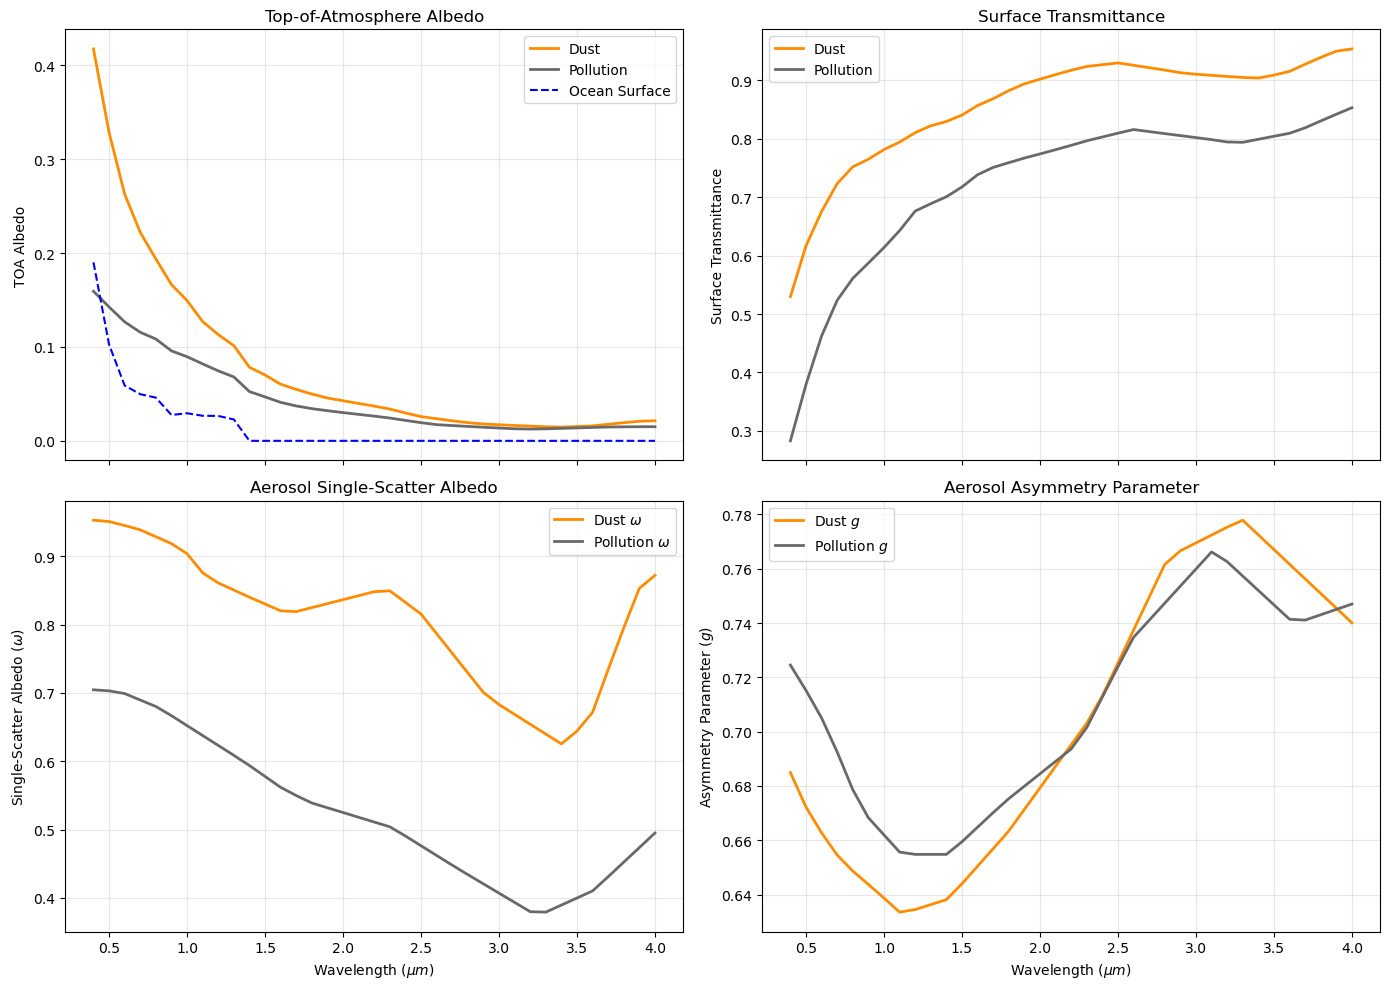

In [11]:
import matplotlib.pyplot as plt

# 1. Calculate the TOA Albedo and Surface Transmittance for Dust
albedo_dust, trans_dust = run_two_stream_model(
    tau_dust, omega_dust, g_dust, 
    tau_R, omega_R, g_R, 
    r_surface
)

# 2. Calculate the TOA Albedo and Surface Transmittance for Pollution
albedo_poll, trans_poll = run_two_stream_model(
    tau_poll, omega_poll, g_poll, 
    tau_R, omega_R, g_R, 
    r_surface
)

# 3. Create a multi-panel plot to visualize the results
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Panel 1: TOA Albedo
axs[0, 0].plot(wavelengths, albedo_dust, label='Dust', color='darkorange', linewidth=2)
axs[0, 0].plot(wavelengths, albedo_poll, label='Pollution', color='dimgray', linewidth=2)
axs[0, 0].plot(wavelengths, r_surface, label='Ocean Surface', color='blue', linestyle='--')
axs[0, 0].set_ylabel('TOA Albedo')
axs[0, 0].set_title('Top-of-Atmosphere Albedo')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Panel 2: Surface Transmittance
axs[0, 1].plot(wavelengths, trans_dust, label='Dust', color='darkorange', linewidth=2)
axs[0, 1].plot(wavelengths, trans_poll, label='Pollution', color='dimgray', linewidth=2)
axs[0, 1].set_ylabel('Surface Transmittance')
axs[0, 1].set_title('Surface Transmittance')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# Panel 3: Single-Scatter Albedo (omega)
axs[1, 0].plot(wavelengths, omega_dust, label='Dust $\omega$', color='darkorange', linewidth=2)
axs[1, 0].plot(wavelengths, omega_poll, label='Pollution $\omega$', color='dimgray', linewidth=2)
axs[1, 0].set_xlabel('Wavelength ($\mu m$)')
axs[1, 0].set_ylabel('Single-Scatter Albedo ($\omega$)')
axs[1, 0].set_title('Aerosol Single-Scatter Albedo')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Panel 4: Asymmetry Parameter (g)
axs[1, 1].plot(wavelengths, g_dust, label='Dust $g$', color='darkorange', linewidth=2)
axs[1, 1].plot(wavelengths, g_poll, label='Pollution $g$', color='dimgray', linewidth=2)
axs[1, 1].set_xlabel('Wavelength ($\mu m$)')
axs[1, 1].set_ylabel('Asymmetry Parameter ($g$)')
axs[1, 1].set_title('Aerosol Asymmetry Parameter')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure1.png', dpi=300) # Saves figure for your repo!
plt.show()

**Let's examine the values given in our data sets (plotted on the bottom) to see if these plots are consistent with what we expect from aerosol scattering properties.**

The most obvious comparison we can observe is the difference in single scatter albedo between dust particles and pollution particles for any given wavelength. Clearly, $\omega_{poll} < \omega_{dust}$ for every wavelength which tells us that pollution is less reflecting and more absorbing than dust. Consequently, we observe that the top-of-atmosphere albedo is consistently higher for dust than it is for pollution. 

In comparing the values of the asymmetry parameter, we see that pollution has higher forward-scattering at lower wavelengths, and lower forward scattering at higher wavelengths. This means that pollution will more scatter purpler light more towards the surface than dust, but tend to scatter less red light towards the surface. This difference is quite subtle, meaning that the difference in $\omega$ values is the true driver of the difference here.

The most significant difference is still the single scatter albedo, which manifests as higher transmittance and reflectance for dust than for pollution, as it absorbs more radiation than dust, sending less to the ToA through reflection and to the surface through transmittance.

## Part II - Shortwave Fluxes and the DRE
### 6.1 - Model Construction

In [14]:
import scipy.integrate as integrate
from scipy.interpolate import interp1d
import pandas as pd
import numpy as np

# ==========================================
# 6.1a: Read in the solar flux F0
# ==========================================
fo_df = pd.read_csv('data/Fo.csv') # Adjust path if necessary

# Convert units to match our model
fo_wavelengths_mu = fo_df['lambda (nm)'].values / 1000.0  # nm to um
fo_flux_mu = fo_df[' TOA Flux (W/m2/nm)'].values * 1000.0 # W/m2/nm to W/m2/um

# Interpolate onto our model's wavelength grid (0.4 to 4.0 um)
interpolator = interp1d(fo_wavelengths_mu, fo_flux_mu, kind='linear', fill_value="extrapolate")
F0_spectral = interpolator(wavelengths)

# ==========================================
# 6.1b: Calculate Upward and Downward Fluxes
# ==========================================

# 1. PRISTINE SKY (No Aerosols, only Rayleigh Layer)
# Re-create zero-tau array just in case it's not in memory
tau_zero = np.zeros_like(wavelengths)

albedo_pristine, trans_pristine = run_two_stream_model(
    tau_zero, omega_dust, g_dust,  
    tau_R, omega_R, g_R, 
    r_surface
)

# 2. Spectrally resolved fluxes (W/m2/um)
# --- Pristine Sky ---
F_up_toa_pristine = F0_spectral * albedo_pristine
F_down_sfc_pristine = F0_spectral * trans_pristine

# --- Dust ---
F_up_toa_dust = F0_spectral * albedo_dust
F_down_sfc_dust = F0_spectral * trans_dust

# --- Pollution ---
F_up_toa_poll = F0_spectral * albedo_poll
F_down_sfc_poll = F0_spectral * trans_poll

# 3. Integrate to estimate broadband SW fluxes (W/m2)
# Using the updated trapezoid method
F0_total = integrate.trapezoid(F0_spectral, wavelengths)

# Upward flux at TOA
F_up_toa_pristine_total = integrate.trapezoid(F_up_toa_pristine, wavelengths)
F_up_toa_dust_total = integrate.trapezoid(F_up_toa_dust, wavelengths)
F_up_toa_poll_total = integrate.trapezoid(F_up_toa_poll, wavelengths)

# Downward flux at Surface
F_down_sfc_pristine_total = integrate.trapezoid(F_down_sfc_pristine, wavelengths)
F_down_sfc_dust_total = integrate.trapezoid(F_down_sfc_dust, wavelengths)
F_down_sfc_poll_total = integrate.trapezoid(F_down_sfc_poll, wavelengths)

print("=== Broadband Shortwave Fluxes ===")
print(f"Total Incoming Solar Flux (F0): {F0_total:.2f} W/m^2\n")
print(f"Pristine - TOA Upward: {F_up_toa_pristine_total:.2f} W/m^2 | SFC Downward: {F_down_sfc_pristine_total:.2f} W/m^2")
print(f"Dust     - TOA Upward: {F_up_toa_dust_total:.2f} W/m^2 | SFC Downward: {F_down_sfc_dust_total:.2f} W/m^2")
print(f"Pollut.  - TOA Upward: {F_up_toa_poll_total:.2f} W/m^2 | SFC Downward: {F_down_sfc_poll_total:.2f} W/m^2")

=== Broadband Shortwave Fluxes ===
Total Incoming Solar Flux (F0): 1239.32 W/m^2

Pristine - TOA Upward: 122.35 W/m^2 | SFC Downward: 1176.87 W/m^2
Dust     - TOA Upward: 252.38 W/m^2 | SFC Downward: 908.78 W/m^2
Pollut.  - TOA Upward: 125.99 W/m^2 | SFC Downward: 678.99 W/m^2


**=== Equations from 'Definitions' Section ===**
1. Top of Atmosphere DRE (Eq. 3) $$DRE_{TOA} = F_{p}^\uparrow - F^\uparrow$$
2. Surface DRE (Eq. 5) $$DRE_{sfc} = (F^\downarrow - F_{p}^\downarrow)(1 - r_{s})$$
3. Atmospheric DRE (Eq. 7) $$DRE_{atm} = DRE_{TOA} - DRE_{sfc}$$

Additionally, atmospheric net fluxes must satisfy (Eq. 6) $$F_{TOA}^N = F_{sfc}^N + F_{atm}^N$$
Which we will use to sanity check this model for section 6.2

In [15]:
# =====================================================================
# 6.1c: Calculate Instantaneous DRE at TOA, Surface, and Atmosphere
# =====================================================================

# --- 1. Spectral DRE Calculations (W/m2/um) ---
# Dust
dre_toa_dust_spectral = F_up_toa_pristine - F_up_toa_dust
dre_sfc_dust_spectral = (F_down_sfc_dust - F_down_sfc_pristine) * (1.0 - r_surface)

# Pollution
dre_toa_poll_spectral = F_up_toa_pristine - F_up_toa_poll
dre_sfc_poll_spectral = (F_down_sfc_poll - F_down_sfc_pristine) * (1.0 - r_surface)


# --- 2. Broadband Integration (W/m2) ---
# Dust Broadband DRE
DRE_toa_dust = integrate.trapezoid(dre_toa_dust_spectral, wavelengths)
DRE_sfc_dust = integrate.trapezoid(dre_sfc_dust_spectral, wavelengths)
DRE_atm_dust = DRE_toa_dust - DRE_sfc_dust  # Eq. 7

# Pollution Broadband DRE
DRE_toa_poll = integrate.trapezoid(dre_toa_poll_spectral, wavelengths)
DRE_sfc_poll = integrate.trapezoid(dre_sfc_poll_spectral, wavelengths)
DRE_atm_poll = DRE_toa_poll - DRE_sfc_poll  # Eq. 7


# --- 3. Print the Final Results ---
print("==================================================")
print("       BROADBAND DIRECT RADIATIVE EFFECT (DRE)    ")
print("==================================================")
print(f"DUST AEROSOL (\u03c4_0.55 = 1.0):")
print(f"  • TOA DRE:         {DRE_toa_dust:6.2f} W/m^2")
print(f"  • Surface DRE:     {DRE_sfc_dust:6.2f} W/m^2")
print(f"  • Atmospheric DRE: {DRE_atm_dust:6.2f} W/m^2")
print("--------------------------------------------------")
print(f"POLLUTION AEROSOL (\u03c4_0.55 = 1.0):")
print(f"  • TOA DRE:         {DRE_toa_poll:6.2f} W/m^2")
print(f"  • Surface DRE:     {DRE_sfc_poll:6.2f} W/m^2")
print(f"  • Atmospheric DRE: {DRE_atm_poll:6.2f} W/m^2")
print("==================================================")

       BROADBAND DIRECT RADIATIVE EFFECT (DRE)    
DUST AEROSOL (τ_0.55 = 1.0):
  • TOA DRE:         -130.03 W/m^2
  • Surface DRE:     -251.54 W/m^2
  • Atmospheric DRE: 121.51 W/m^2
--------------------------------------------------
POLLUTION AEROSOL (τ_0.55 = 1.0):
  • TOA DRE:          -3.64 W/m^2
  • Surface DRE:     -466.73 W/m^2
  • Atmospheric DRE: 463.09 W/m^2


## 6.2 Verification of Fluxes and DRE Values (Energy Conservation)

To ensure that our flux integration and DRE calculations are physically sound, we test for **First-Law Thermodynamic Energy Conservation**. 

### Test 1: Conservative Atmosphere Check (Pristine Sky)
By definition, Rayleigh scattering is a purely conservative process ($\omega = 1.0$). Therefore, a pristine atmosphere cannot absorb any shortwave radiation. The net energy entering the top of the atmosphere must exactly balance the net energy absorbed at the surface:
$$F_{TOA, net}^{pristine} = F_{sfc, net}^{pristine}$$
Where:
* $F_{TOA, net} = F_0 - F^{\uparrow}_{TOA}$
* $F_{sfc, net} = F^{\downarrow}_{sfc} \cdot (1 - r_s)$

### Test 2: DRE-Absorption Closure
The atmospheric radiative effect ($DRE_{atm} = DRE_{TOA} - DRE_{sfc}$) represents the net gain or loss of captured energy within the atmospheric column due to aerosols. We verify that this closure matches the explicit difference in column absorption ($A$):
$$DRE_{atm} = A_{perturbed} - A_{pristine}$$
where column absorption is defined as $A = F_{TOA, net} - F_{sfc, net}$.

In [18]:
# =====================================================================
# 6.2: Energy Conservation & Closure Verification
# =====================================================================

# --- 1. Calculate Broadband Net Fluxes (W/m2) ---
# Net TOA Flux = Downward (F0) - Upward
F_net_toa_pristine = F0_total - F_up_toa_pristine_total
F_net_toa_dust     = F0_total - F_up_toa_dust_total
F_net_toa_poll     = F0_total - F_up_toa_poll_total

# Net Surface Flux = Downward absorbed by ocean = integrated( F_down * (1 - r_s) )
F_net_sfc_pristine = integrate.trapezoid(F_down_sfc_pristine * (1.0 - r_surface), wavelengths)
F_net_sfc_dust     = integrate.trapezoid(F_down_sfc_dust * (1.0 - r_surface), wavelengths)
F_net_sfc_poll     = integrate.trapezoid(F_down_sfc_poll * (1.0 - r_surface), wavelengths)

# --- 2. Calculate Column Absorption (W/m2) ---
Abs_pristine = F_net_toa_pristine - F_net_sfc_pristine
Abs_dust     = F_net_toa_dust - F_net_sfc_dust
Abs_poll     = F_net_toa_poll - F_net_sfc_poll


# --- 3. Run Verification Evaluations ---
# Test 1: Is pristine sky absorption zero?
test1_passed = np.isclose(Abs_pristine, 0.0, atol=1e-5)

# Test 2: Does DRE_atm equal the delta in column absorption?
test2_dust_passed = np.isclose(DRE_atm_dust, (Abs_dust - Abs_pristine), atol=1e-5)
test2_poll_passed = np.isclose(DRE_atm_poll, (Abs_poll - Abs_pristine), atol=1e-5)


# --- 4. Print Verification Report ---
print("==================================================")
print("             FLUX & DRE VERIFICATION REPORT       ")
print("==================================================")
print(f"Pristine Column Absorption:             {Abs_pristine:6.4f} W/m^2")
print(f"--> TEST 1 (Pristine Absorption = 0):   {'✅ PASSED' if test1_passed else '❌ FAILED'}")
print("--------------------------------------------------")
print(f"Dust DRE_atm Closure Delta:             {abs(DRE_atm_dust - (Abs_dust - Abs_pristine)):6.4e} W/m^2")
print(f"--> TEST 2a (Dust DRE Closure):         {'✅ PASSED' if test2_dust_passed else '❌ FAILED'}")
print("--------------------------------------------------")
print(f"Pollution DRE_atm Closure Delta:        {abs(DRE_atm_poll - (Abs_poll - Abs_pristine)):6.4e} W/m^2")
print(f"--> TEST 2b (Pollution DRE Closure):    {'✅ PASSED' if test2_poll_passed else '❌ FAILED'}")
print("==================================================")

             FLUX & DRE VERIFICATION REPORT       
Pristine Column Absorption:             0.0000 W/m^2
--> TEST 1 (Pristine Absorption = 0):   ✅ PASSED
--------------------------------------------------
Dust DRE_atm Closure Delta:             1.9895e-13 W/m^2
--> TEST 2a (Dust DRE Closure):         ✅ PASSED
--------------------------------------------------
Pollution DRE_atm Closure Delta:        1.1369e-13 W/m^2
--> TEST 2b (Pollution DRE Closure):    ✅ PASSED


### 6.3 - Questions

Firstly, let's paste the DRE results from 6.1 here again for convenience:

In [19]:
# --- 3. (Re)Print the Final Results ---
print("==================================================")
print("       BROADBAND DIRECT RADIATIVE EFFECT (DRE)    ")
print("==================================================")
print(f"DUST AEROSOL (\u03c4_0.55 = 1.0):")
print(f"  • TOA DRE:         {DRE_toa_dust:6.2f} W/m^2")
print(f"  • Surface DRE:     {DRE_sfc_dust:6.2f} W/m^2")
print(f"  • Atmospheric DRE: {DRE_atm_dust:6.2f} W/m^2")
print("--------------------------------------------------")
print(f"POLLUTION AEROSOL (\u03c4_0.55 = 1.0):")
print(f"  • TOA DRE:         {DRE_toa_poll:6.2f} W/m^2")
print(f"  • Surface DRE:     {DRE_sfc_poll:6.2f} W/m^2")
print(f"  • Atmospheric DRE: {DRE_atm_poll:6.2f} W/m^2")
print("==================================================")

       BROADBAND DIRECT RADIATIVE EFFECT (DRE)    
DUST AEROSOL (τ_0.55 = 1.0):
  • TOA DRE:         -130.03 W/m^2
  • Surface DRE:     -251.54 W/m^2
  • Atmospheric DRE: 121.51 W/m^2
--------------------------------------------------
POLLUTION AEROSOL (τ_0.55 = 1.0):
  • TOA DRE:          -3.64 W/m^2
  • Surface DRE:     -466.73 W/m^2
  • Atmospheric DRE: 463.09 W/m^2


a. For $\tau_{a,0.55} = 1$, $$DRE_{TOA,dust} = -130.03 \frac{W}{m^2}, DRE_{TOA,poll} = -3.64 \frac{W}{m^2}$$ 

The cause of this difference, of course, is the difference in single-scatter albedo per wavelength examined in **section 5.3**. $DRE_{TOA}$ is a representative value of the difference between pristine-sky upward flux and the real upward flux from the aerosol data. Under clear-sky conditions, the only upward flux would be from surface reflectance, but aerosol effects cause scattering events which reflect more photons upwards than the surface does alone. Naturally, the higher $\omega$ values of dust particles means that it reflects more radiation towards the top of the atmosphere, hence the more negative value than that of pollution.

b. A *negative* value of TOA DRE means that the presence of aerosols is *increasing* the earth's albedo, rejecting *more* solar radiation to the top of the atmosphere than would a clear "pristine" atmosphere. Since more energy is being sent back out to space, this would have a *cooling* effect on the climate system.

c. The values of Atmospheric DRE shows us the amount of energy trapped within each aerosol layer, and Surface DRE shows us the amount of energy sent to the surface relative to a clear "pristine" atmosphere. The highly negative values for surface DRE show a cooling effect on the surface, while the highly positive values for atmospheric DRE show a warming effect for each aerosol layer. This creates a temperature gradient between the surface and the atmosphere layers. Further, the atmospheric DRE for pollution is *much* higher than that of dust, which exacerbates this temperature gradient within these layers of the atmosphere. Convection is driven by vertical temperature gradients, by which hot air rises from the surface. However, these aerosol layers essentially squash that temperature gradient by cooling the surface and warming the atmosphere, making a highly stable environment that inhibits atmospheric convection.

d. Let's plot this. Instead of using our CSV reflectance values, we'll use a wider range of surface reflectance values for very dark and very bright surfaces to try to exacernate any differences between pollution and dust aerosols.

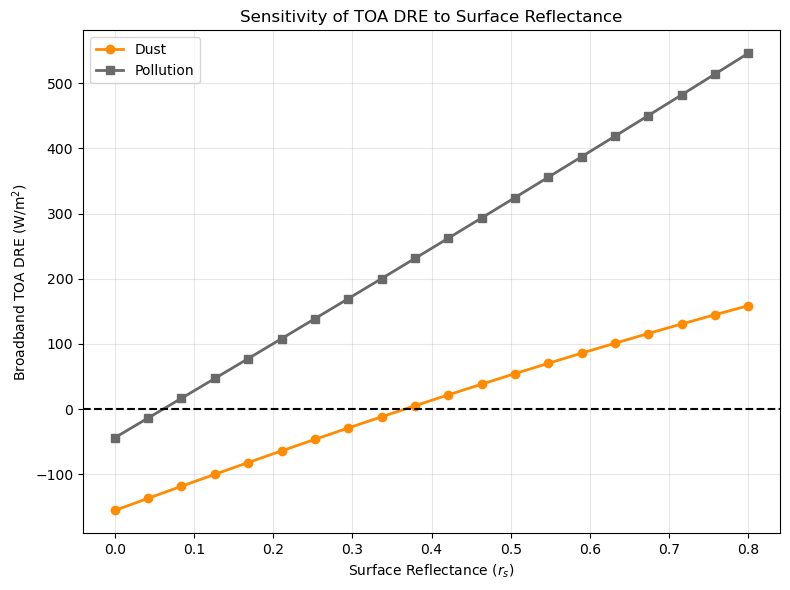

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# 1. Define a range of surface reflectances (spectrally flat for simplicity)
rs_values = np.linspace(0.0, 0.8, 20)

dre_toa_dust_list = []
dre_toa_poll_list = []

# 2. Loop over each surface reflectance value and compute DRE
for rs in rs_values:
    # Pristine Sky
    albedo_pris, _ = run_two_stream_model(tau_zero, omega_dust, g_dust, tau_R, omega_R, g_R, rs)
    F_up_toa_pris = F0_spectral * albedo_pris
    
    # Dust
    albedo_d, _ = run_two_stream_model(tau_dust, omega_dust, g_dust, tau_R, omega_R, g_R, rs)
    F_up_toa_d = F0_spectral * albedo_d
    
    # Pollution
    albedo_p, _ = run_two_stream_model(tau_poll, omega_poll, g_poll, tau_R, omega_R, g_R, rs)
    F_up_toa_p = F0_spectral * albedo_p
    
    # Calculate Spectral DRE
    dre_toa_d_spec = F_up_toa_pris - F_up_toa_d
    dre_toa_p_spec = F_up_toa_pris - F_up_toa_p
    
    # Integrate to Broadband DRE
    dre_toa_dust_list.append(integrate.trapezoid(dre_toa_d_spec, wavelengths))
    dre_toa_poll_list.append(integrate.trapezoid(dre_toa_p_spec, wavelengths))

# 3. Plot the results
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(rs_values, dre_toa_dust_list, label='Dust', color='darkorange', linewidth=2, marker='o')
ax.plot(rs_values, dre_toa_poll_list, label='Pollution', color='dimgray', linewidth=2, marker='s')

# Add a zero line to separate warming (+) from cooling (-)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)

ax.set_xlabel('Surface Reflectance ($r_s$)')
ax.set_ylabel('Broadband TOA DRE (W/m$^2$)')
ax.set_title('Sensitivity of TOA DRE to Surface Reflectance')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure2.png', dpi=300) # Saves figure for your repo!
plt.show()

As we can see, pollution is *much* more sensitive to changes in surface reflectance than dust. Because dust is much more highly scattering, it retains its cooling effect for a much broader range of surfaces, only crossing the zero line for $r_{s} ~ 0.38$, representing very bright surfaces, upon which dust is literally darker than the surface beneath it. Pollution however, is quite dark, and relies on very dark surfaces (such as the ocean) to have any kind of cooling effect. As soon as pollution is over brighter, more reflecting land, it starts to have an incredibly significant warming effect.

In the final analysis, **No,** changes in surface reflectance do *not* have a similar effect on both types of aerosols.

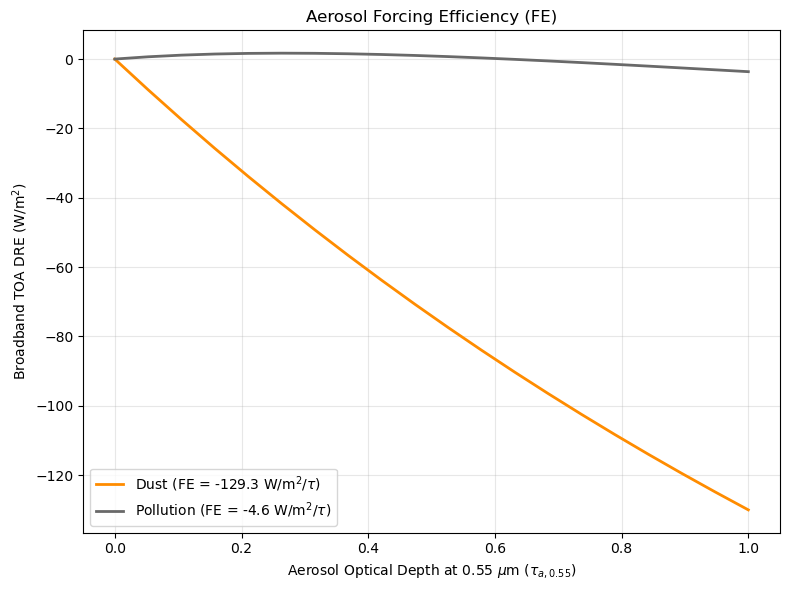

=== TOA Forcing Efficiency ===
Dust FE:      -129.32 W/m^2 per unit optical depth
Pollution FE: -4.57 W/m^2 per unit optical depth


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# 1. Define an array of optical depth scalings (from tau = 0 to tau = 1.0)
tau_scalars = np.linspace(0.0, 1.0, 20)

dre_toa_dust_fe = []
dre_toa_poll_fe = []

# 2. Loop through the optical depths
for scale in tau_scalars:
    # Scale the original optical depth arrays
    t_dust = tau_dust * scale
    t_poll = tau_poll * scale
    
    # Calculate System Albedo for both scaled aerosols
    albedo_d, _ = run_two_stream_model(t_dust, omega_dust, g_dust, tau_R, omega_R, g_R, r_surface)
    albedo_p, _ = run_two_stream_model(t_poll, omega_poll, g_poll, tau_R, omega_R, g_R, r_surface)
    
    # Calculate Upwelling TOA Fluxes
    F_up_toa_d = F0_spectral * albedo_d
    F_up_toa_p = F0_spectral * albedo_p
    
    # Spectral DRE
    dre_toa_d_spec = F_up_toa_pristine - F_up_toa_d
    dre_toa_p_spec = F_up_toa_pristine - F_up_toa_p
    
    # Integrate and append to lists
    dre_toa_dust_fe.append(integrate.trapezoid(dre_toa_d_spec, wavelengths))
    dre_toa_poll_fe.append(integrate.trapezoid(dre_toa_p_spec, wavelengths))

# 3. Calculate Forcing Efficiency (FE) using linear regression (polyfit)
# np.polyfit returns [slope, intercept]
FE_dust = np.polyfit(tau_scalars, dre_toa_dust_fe, 1)[0]
FE_poll = np.polyfit(tau_scalars, dre_toa_poll_fe, 1)[0]

# 4. Plot the results
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tau_scalars, dre_toa_dust_fe, label=f'Dust (FE = {FE_dust:.1f} W/m$^2$/$\\tau$)', color='darkorange', linewidth=2)
ax.plot(tau_scalars, dre_toa_poll_fe, label=f'Pollution (FE = {FE_poll:.1f} W/m$^2$/$\\tau$)', color='dimgray', linewidth=2)

ax.set_xlabel('Aerosol Optical Depth at 0.55 $\mu$m ($\\tau_{a,0.55}$)')
ax.set_ylabel('Broadband TOA DRE (W/m$^2$)')
ax.set_title('Aerosol Forcing Efficiency (FE)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure3.png', dpi=300) # Saves figure for your repo!
plt.show()

print("=== TOA Forcing Efficiency ===")
print(f"Dust FE:      {FE_dust:.2f} W/m^2 per unit optical depth")
print(f"Pollution FE: {FE_poll:.2f} W/m^2 per unit optical depth")

e. **The magnitude of the slope** of dust is significantly larger than that of pollution, meaning that its **Forcing Efficiency is much higher than pollution**. What this means this that every new particle of dust added to the atmosphere chamges the TOA energy balance *much* more aggresively than pollution. This makes sense, given dust's much higher single-scattering albedo. Because pollution is much more absorbing than dust, adding more pollution to the atmosphere just traps more heat inside the atmosphere rather than reflecting it out to space, so its TOA energy balance is less sensitive than dust's. 

### Part III - Student Investigation

**Question:** Does the vertical ordering of the aerosol layers matter, and if so, how significant is the difference in TOA DRE?

**Hypothesis:** Order should matter. For example, placing the highly absorbing layer of pollution *over* dust should result in a much lower TOA DRE than placing dust over pollution. 

In [25]:
import scipy.integrate as integrate

def run_three_layer_model(tau1, omega1, g1, tau2, omega2, g2, tau3, omega3, g3, r_surface):
    """
    Stacks Layer 1 (Top), Layer 2 (Middle), Layer 3 (Bottom Rayleigh), and the Surface.
    """
    # 1. Solve isolated layers
    R1, T1 = solve_single_layer(tau1, omega1, g1)
    R2, T2 = solve_single_layer(tau2, omega2, g2)
    R3, T3 = solve_single_layer(tau3, omega3, g3)
    
    # 2. Combine Layer 1 and Layer 2 -> Layer 12
    denom_12 = 1.0 - R1 * R2
    R12 = R1 + (T1**2 * R2) / denom_12
    T12 = (T1 * T2) / denom_12
    
    # 3. Combine Layer 12 and Layer 3 -> Layer 123
    denom_123 = 1.0 - R12 * R3
    R123 = R12 + (T12**2 * R3) / denom_123
    T123 = (T12 * T3) / denom_123
    
    # 4. Combine with Ocean Surface
    albedo_toa = R123 + (T123**2 * r_surface) / (1.0 - R123 * r_surface)
    
    return albedo_toa

# =================================================================
# Run the Experiment
# =================================================================

# We will use half the optical depth for each so the total column tau is still 1.0
t_dust_half = tau_dust * 0.5
t_poll_half = tau_poll * 0.5

# Case A: Pollution on Top, Dust in Middle
albedo_poll_over_dust = run_three_layer_model(
    t_poll_half, omega_poll, g_poll,  # Top
    t_dust_half, omega_dust, g_dust,  # Middle
    tau_R, omega_R, g_R,              # Bottom
    r_surface
)

# Case B: Dust on Top, Pollution in Middle
albedo_dust_over_poll = run_three_layer_model(
    t_dust_half, omega_dust, g_dust,  # Top
    t_poll_half, omega_poll, g_poll,  # Middle
    tau_R, omega_R, g_R,              # Bottom
    r_surface
)

# Calculate Broadband TOA Upwelling Fluxes
F_up_poll_over_dust = integrate.trapezoid(F0_spectral * albedo_poll_over_dust, wavelengths)
F_up_dust_over_poll = integrate.trapezoid(F0_spectral * albedo_dust_over_poll, wavelengths)

# Calculate DRE
dre_poll_over_dust = F_up_toa_pristine_total - F_up_poll_over_dust
dre_dust_over_poll = F_up_toa_pristine_total - F_up_dust_over_poll

print("=== PART III: AEROSOL SHIELDING EFFECT INVESTIGATION ===")
print("Total Column Aerosol Optical Depth = 1.0 (0.5 Dust + 0.5 Pollution)")
print(f"Pristine Sky Upwelling Flux:      {F_up_toa_pristine_total:.2f} W/m^2\n")
print(f"CASE A (Pollution over Dust):     {dre_poll_over_dust:.2f} W/m^2 (TOA DRE)")
print(f"CASE B (Dust over Pollution):     {dre_dust_over_poll:.2f} W/m^2 (TOA DRE)")
print("---------------------------------------------------------")
print(f"Difference (Shielding Effect):    {abs(dre_poll_over_dust - dre_dust_over_poll):.2f} W/m^2")

=== PART III: AEROSOL SHIELDING EFFECT INVESTIGATION ===
Total Column Aerosol Optical Depth = 1.0 (0.5 Dust + 0.5 Pollution)
Pristine Sky Upwelling Flux:      122.35 W/m^2

CASE A (Pollution over Dust):     -39.54 W/m^2 (TOA DRE)
CASE B (Dust over Pollution):     -76.41 W/m^2 (TOA DRE)
---------------------------------------------------------
Difference (Shielding Effect):    36.87 W/m^2


Sure enough, the vertical order does matter. When pollution rises above more reflective layers, the TOA DRE drops by about half, leading to a warmer result than if the order is reversed. For climate modelling, this exact phonomenon makes trying to predict the impact of dark, polluting layers (such as smoke from wildfires) on the atmosphere quite hard, as this smoke may or may not rise over highly reflective stratocumulus clouds, drastically changing the resulting TOA DRE.

### AI Usage:
+ Tool Used: Google's Gemini Pro
+ AI model wrote most python code
+ In the first iteration of this homework assignment, major issues arose from incorrectly reading the imported .csv files. In this iteration, the successful read of these files was checked independently. The verification tests were designed mostly independently, with some input from Gemini (namely making the "verification reports" look pretty for the output.
+ In the first iteration of this assignment, the "major issue" in question was the atmospheric DRE value output. For dust, this value read a **negative,** which is physically impossible. This led me to go back and realize that the code I had simply accepted from Gemini was horrifically incorrect, leading me to restart the assignment altogether in this new file. Checking that this problem did not re-arise was an exemplary personal verification.

*Note, the "first iteration" in question has been left in this environment folder named "DISREGARD," because I just didn't have the heart to delete the entire old file after starting a new one. It'll stay there as a reminder of what lazy work can get you, that is, several wasted hours.*